# 🖌️ Segmentação via Texto com CLIPSeg (Hugging Face)

Este notebook utiliza o modelo **`CIDAS/clipseg-rd64-refined`** para segmentar objetos baseando-se em **prompts de texto**.

### ✨ Como funciona?
Diferente da detecção tradicional, o **CLIPSeg** permite que você escreva o que deseja encontrar (ex: "cachorro", "caneca", "árvore") e ele gera uma máscara de segmentação indicando exatamente onde o objeto está.

In [1]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import torch
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print(f"Torch version: {torch.__version__}")

/home/zacky/Área de Trabalho/Github_Projects/Visão Computacional de Soma (Python)/Reconhecimento-e-Soma-de-Digitos-com-Vis-o-Computacional/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.11.0+cu130


### 🛠 Configuração do Modelo e Processador

In [2]:
MODEL_NAME = "CIDAS/clipseg-rd64-refined"
IMAGE_DIR = "imagens"

print("Carregando CLIPSeg... aguarde um instante.")
processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)
model = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)
print("Modelo pronto para segmentar!")

Carregando CLIPSeg... aguarde um instante.


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 462/462 [00:00<00:00, 2880.72it/s]
CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo pronto para segmentar!


### 🔍 Configuração dos Prompts e Processamento

> **IMPORTANTE**: Altere a lista em `prompts` para o que você deseja encontrar nas fotos!

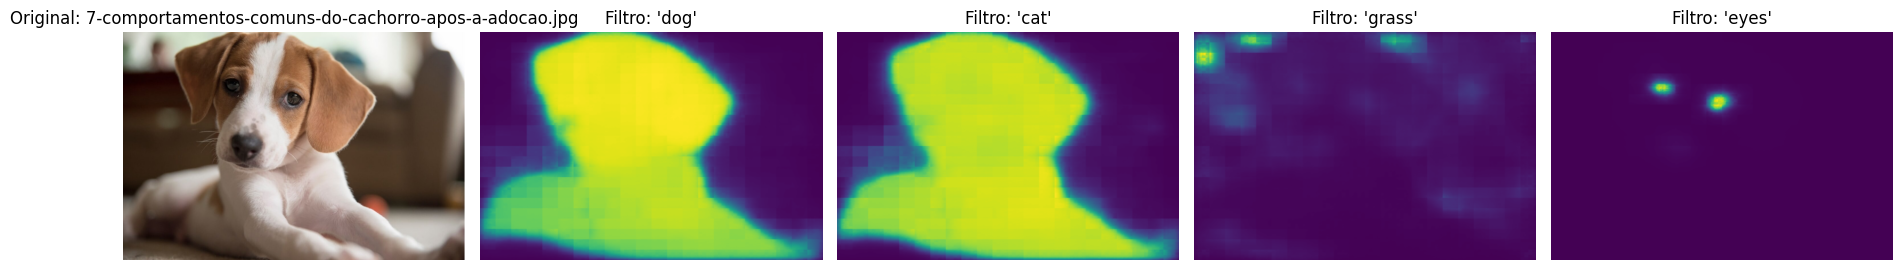

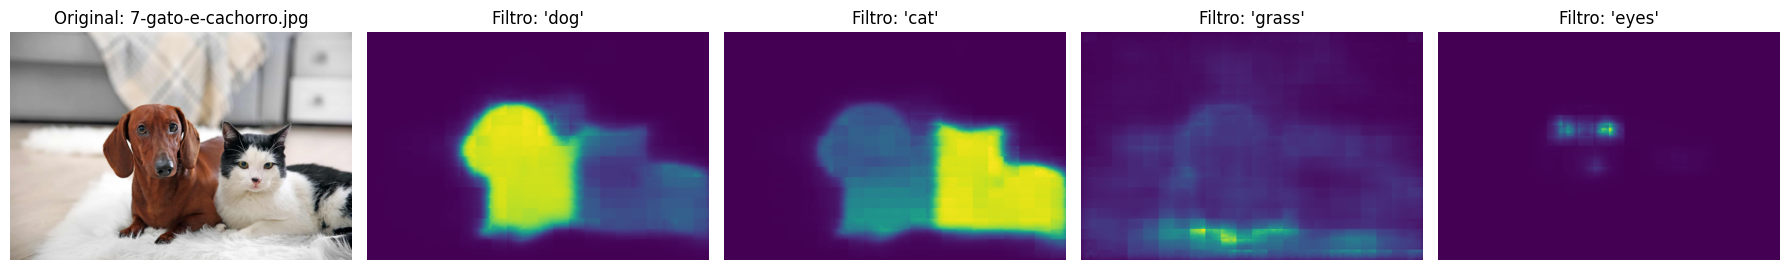

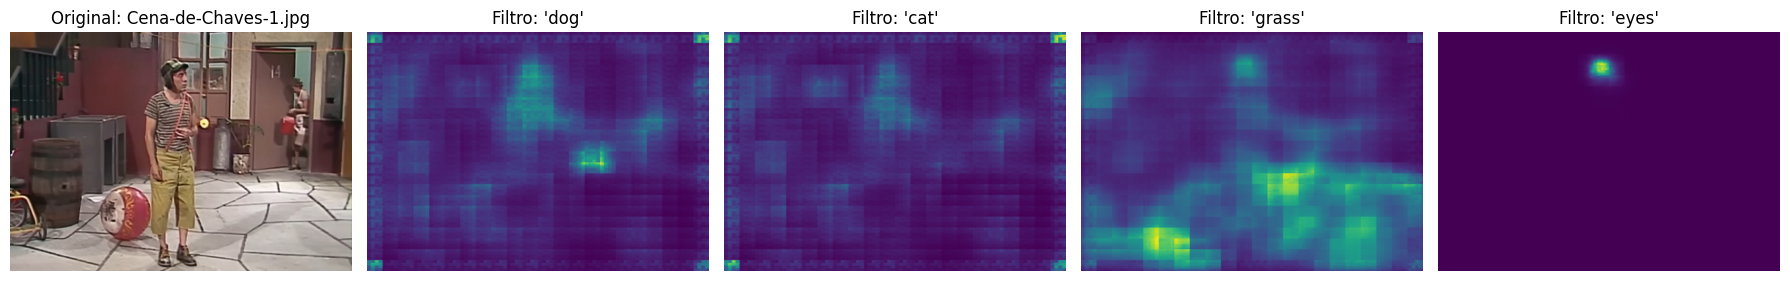

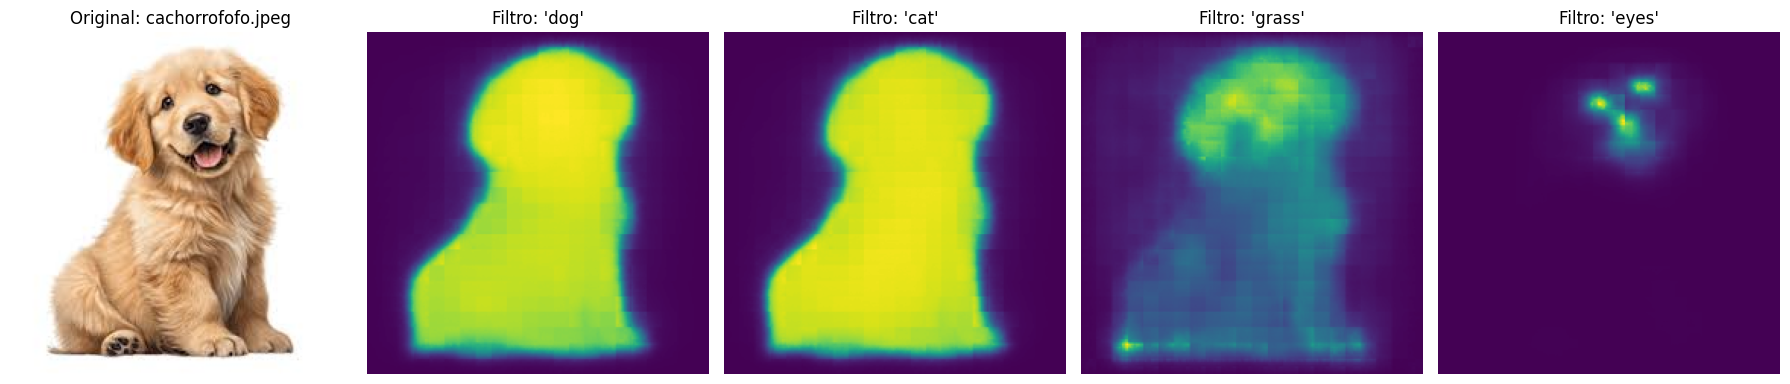

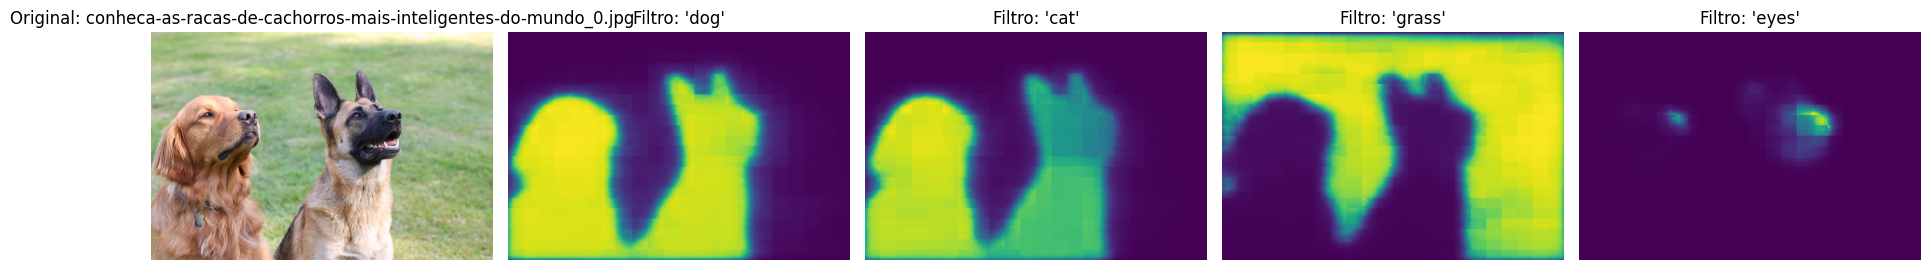

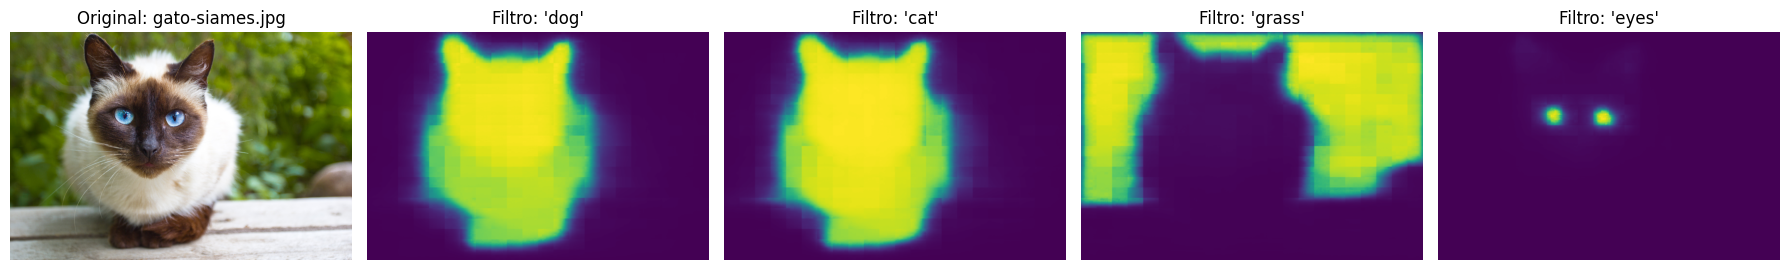

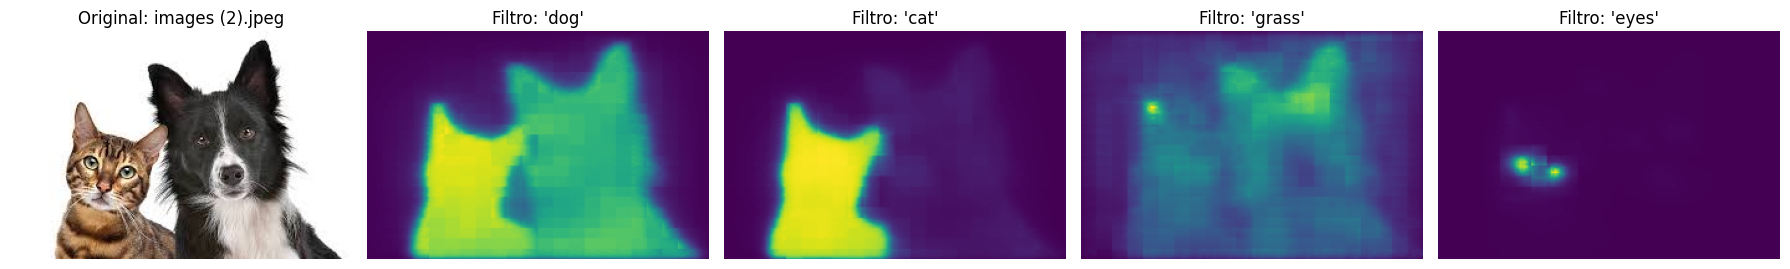

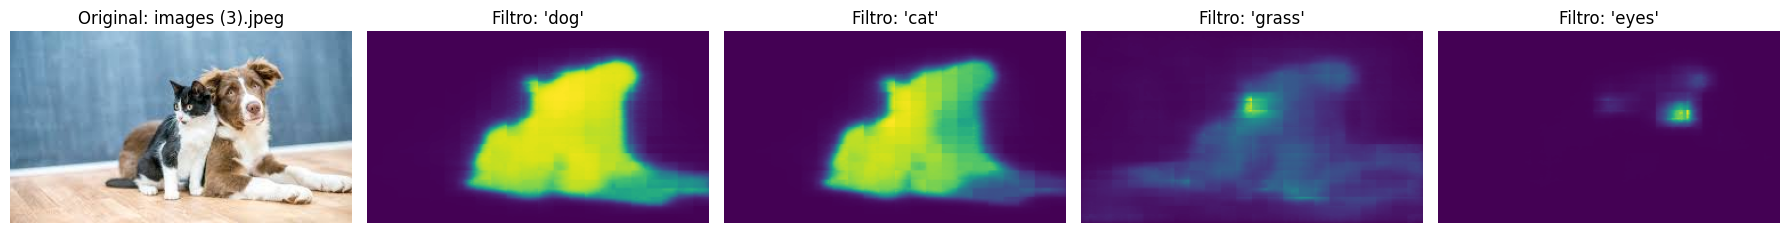

In [3]:
# Liste abaixo o que você deseja segmentar (em inglês costuma funcionar melhor)
prompts = ["dog", "cat", "grass", "eyes"]

valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(valid_extensions)])

for filename in image_files:
    path = os.path.join(IMAGE_DIR, filename)
    image = Image.open(path).convert("RGB")
    
    # Processamento
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Pós-processamento: Redimensionando as predições para o tamanho original da imagem
    preds = torch.sigmoid(outputs.logits)
    
    # Visualização
    num_prompts = len(prompts)
    fig, ax = plt.subplots(1, num_prompts + 1, figsize=(18, 5))
    
    # Mostra a imagem original
    ax[0].imshow(image)
    ax[0].set_title(f"Original: {filename}")
    ax[0].axis('off')
    
    for i in range(num_prompts):
        # Transformando a saída para o tamanho original
        mask = torch.nn.functional.interpolate(
            preds[i].unsqueeze(0).unsqueeze(0), 
            size=(image.size[1], image.size[0]), 
            mode="bilinear"
        ).squeeze().cpu().numpy()
        
        # Exibindo o heatmap (máscara)
        ax[i+1].imshow(mask, cmap='viridis')
        ax[i+1].set_title(f"Filtro: '{prompts[i]}'")
        ax[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()